# Práctica 6 : Detección y comparación de huellas dactilares
## Miembros del equipo:
- Luna Yue Hernández Guerra
- Jorge Lorenzo Lorenzo
---
## Hipotésis Base
La hipótesis base se encuentra explicada en el archivo `Hipotesis_No_IA.md`.

## Desarrollo
### Preprocesamiento de imágenes
Se utilizaron las técnica de preprocesamiento indicadas en la `Hipotesis_No_IA.md` para mejorar la calidad de las imágenes de huellas dactilares antes de aplicar el algoritmo SIFT. Las técnicas incluyeron:

**Librerías necesarias**

Se han utilizado las siguientes librerías:

In [2]:
from fileinput import filename
import os
import cv2 as cv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm

**Buscar y segmentar la ROI**: Se identificó y segmentó la región de interés (ROI) en las imágenes de huellas dactilares para enfocarse en las áreas relevantes.

- `mejor_roi_por_negros` : Esta función se encarga de buscar la zona con más pixeles "negros" donde deducimos que se encuentra el centro de la huella dactilar, para ignorar los bordes blancos

- `recortar_roi` : Recorre todas las carpetas de usuarios y convierte las imágenes a blanco y negro, luego llama a la función `mejor_roi_por_negros` para quedarse con solo la huella.


In [3]:
# PREPROCESADO: Buscar y segmentar la ROI
def mejor_roi_por_negros(image, ventana=500, paso=20):
    """Encuentra la región de interés (ROI) en la imagen que contiene la mayor cantidad de píxeles negros."""

    H, W = image.shape
    w = min(ventana, W, H)
    h = min(ventana, W, H)
    mejor_ventana = (0, 0, w, h)
    mejor_suma = -1

    for y in range(0, H - h + 1, paso):
        for x in range(0, W - w + 1, paso):
            region = image[y:y+h, x:x+w]
            suma = np.sum(region == 0)

            if suma > mejor_suma:
                mejor_suma = suma
                mejor_ventana = (x, y, w, h)

    return mejor_ventana

def recortar_roi(db_path, out_path, ventana=500, paso=15):
    """
    Detecta si db_path contiene carpetas de usuarios (Data) o imágenes sueltas (Test)
    y aplica el recorte ROI guardando en la estructura correspondiente.
    """

    if not os.path.exists(db_path):
        return

    items = os.listdir(db_path)

    images = [f for f in items if f.lower().endswith(('.png', '.jpg'))] # Datos de Test
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))] # Datos de Data

    tareas = [] # Lista de tuplas (origen, destino)

    if len(images) > 0:
        # MODO TEST
        dst_folder = os.path.join(out_path, "roi")
        tareas.append((db_path, dst_folder))
    else:
        # MODO DATA
        for user in users:
            src = os.path.join(db_path, user)
            dst = os.path.join(out_path, user, "roi")
            tareas.append((src, dst))

    for src_dir, dst_dir in tareas:
        os.makedirs(dst_dir, exist_ok=True)
        files = [f for f in os.listdir(src_dir) if f.lower().endswith(".png")]
        
        for filename in files:
            img_path = os.path.join(src_dir, filename)
            img = cv.imread(img_path)

            if img is None: continue

            gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            _, image = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
            x, y, w, h = mejor_roi_por_negros(image, ventana=ventana, paso=paso)
            roi = img[y:y+h, x:x+w]
            cv.imwrite(os.path.join(dst_dir, filename), roi)

**Ecualizar y normalizar el histograma**: Se realiza para definir mejor la huella, para ello se usa la función:

- `ecualizar_histograma` : Esta función ejecuta el método de OpenCV `cv2.equalizeHist` para mejorar el contraste de la imagen, conviertiendo los grises oscuros a negros y los grises claros a blancos.


In [4]:
# PREPROCESADO: Ecualizar y normalizar el histograma
def ecualizar_histograma(db_path, out_path):
    """Ecualiza y normaliza el histograma de las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    tareas = []

    if len(images) > 0:
        # MODO TEST
        src = os.path.join(out_path, "roi")
        dst = os.path.join(out_path, "equalized")
        if os.path.isdir(src):
            tareas.append((src, dst))
    else:
        # MODO DATA
        for user in users:
            src = os.path.join(out_path, user, "roi")
            dst = os.path.join(out_path, user, "equalized")
            if os.path.isdir(src):
                tareas.append((src, dst))

    for src_dir, dst_dir in tareas:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            equalized = cv.equalizeHist(gray)
            cv.imwrite(os.path.join(dst_dir, filename), equalized)

**Aplicar un filtro bilateral**: Se utiliza para reducir el ruido mientras se preservan los bordes, es necesario para mantener los detalles de la huella dactilar. Se utiliza la siguiente función:

- `aplicar_filtro_bilateral` : Esta función aplica un filtro bilateral usando OpenCV para suavizar la imagen mientras mantiene los bordes definidos.


In [5]:
# PREPROCESADO: Aplicar un filtro bilateral
def aplicar_filtro_bilateral(db_path, out_path):
    """Aplica un filtro bilateral a las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    tareas = []

    if len(images) > 0:
        # MODO TEST
        src = os.path.join(out_path, "equalized")
        dst = os.path.join(out_path, "bilateral_filter")
        if os.path.isdir(src):
            tareas.append((src, dst))
    else:
        # MODO DATA
        for user in users:
            src = os.path.join(out_path, user, "equalized")
            dst = os.path.join(out_path, user, "bilateral_filter")
            if os.path.isdir(src):
                tareas.append((src, dst))

    for src_dir, dst_dir in tareas:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            bilateral = cv.bilateralFilter(gray, d=10, sigmaColor=10, sigmaSpace=10)
            cv.imwrite(os.path.join(dst_dir, filename), bilateral)

**Aplicar un realce de crestas**: Se utiliza para resaltar las crestas de la huella dactilar, facilitando la detección de características clave. Se utiliza la siguiente función:

- `realzar_crestas` : Esta función utiliza el filtros de Sobel calculando los cambios de intesisdad horizontal y verticial, y los commbina, esto te permite tener una imagen donde las crestas están más definidas.


In [6]:
# PREPROCESADO: Aplicar un realce de crestas
def realzar_crestas(db_path, out_path):
    """Aplica un realce de crestas a las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    tareas = []

    if len(images) > 0:
        # MODO TEST
        src = os.path.join(out_path, "bilateral_filter")
        dst = os.path.join(out_path, "sobel")
        if os.path.isdir(src):
            tareas.append((src, dst))
    else:
        # MODO DATA
        for user in users:
            src = os.path.join(out_path, user, "bilateral_filter")
            dst = os.path.join(out_path, user, "sobel")
            if os.path.isdir(src):
                tareas.append((src, dst))

    for src_dir, dst_dir in tareas:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
            sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)

            sobel = cv.magnitude(sobelx, sobely)
            sobel_8u = cv.normalize(sobel, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)
            cv.imwrite(os.path.join(dst_dir, filename), sobel_8u)

**Refinar la ROI**: Se utiliza para hacer una limpieza final, se utiliza la función siguiente:

- `refinar_roi` : Realiza un recorte del margen en un 3% para quitar bordes blancos y aplica `cv.morphologyEx` para limpiar la imagen de imperfecciones y también `cv.medianBlur` para eliminar ruido.

Es importante recalcar que se ha utilizado `Geminis` para utilizar el preprocesado para los datos de entrenamiento y test, para facilitar la ejecución del código.


In [7]:
# PREPROCESADO: Refinar la ROI
def refinar_roi(db_path, out_path):
    """Refina la ROI de las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    tareas = []

    if len(images) > 0:
        # MODO TEST
        src = os.path.join(out_path, "sobel")
        dst = os.path.join(out_path, "refinadas")
        if os.path.isdir(src):
            tareas.append((src, dst))
    else:
        # MODO DATA
        for user in users:
            src = os.path.join(out_path, user, "sobel")
            dst = os.path.join(out_path, user, "refinadas")
            if os.path.isdir(src):
                tareas.append((src, dst))

    for src_dir, dst_dir in tareas:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith(".png")]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
            if image is None: continue

            h, w = image.shape
            pct = 0.03
            m = int(min(h, w) * pct)
            crop = image[m:h-m, m:w-m]
            kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
            clean = cv.morphologyEx(crop, cv.MORPH_OPEN, kernel, iterations=1)
            clean = cv.medianBlur(clean, 3)
            refinada = cv.normalize(clean, None, 0, 255, cv.NORM_MINMAX)
            cv.imwrite(os.path.join(dst_dir, filename), refinada)

#### Ejecución del preprocesado

In [8]:
DB_PATH = r"data"
OUT_PATH = "output"

TEST_PATH = "test"
OUT_TEST_PATH = "output/test"

print(20*"=")
print("PREPROCESADO BASE DE DATOS (DATA)")
print(20*"=")

print("Paso 1. ROI (Data)")
recortar_roi(DB_PATH, OUT_PATH, ventana=500, paso=15)  
print("Paso 2. Ecualizar (Data)")
ecualizar_histograma(DB_PATH, OUT_PATH)
print("Paso 3. Bilateral (Data)")
aplicar_filtro_bilateral(DB_PATH, OUT_PATH)
print("Paso 4. Sobel (Data)")
realzar_crestas(DB_PATH, OUT_PATH)
print("Paso 5. Refinar (Data)")
refinar_roi(DB_PATH, OUT_PATH)

print(20*"=")
print("PREPROCESADO IMÁGENES DE TEST")
print(20*"=")

print("Paso 1. ROI (Test)")
recortar_roi(TEST_PATH, OUT_TEST_PATH, ventana=500, paso=15)
print("Paso 2. Ecualizar (Test)")
ecualizar_histograma(TEST_PATH, OUT_TEST_PATH)
print("Paso 3. Bilateral (Test)")
aplicar_filtro_bilateral(TEST_PATH, OUT_TEST_PATH)
print("Paso 4. Sobel (Test)")
realzar_crestas(TEST_PATH, OUT_TEST_PATH)
print("Paso 5. Refinar (Test)")
refinar_roi(TEST_PATH, OUT_TEST_PATH)

PREPROCESADO BASE DE DATOS (DATA)
Paso 1. ROI (Data)
Paso 2. Ecualizar (Data)
Paso 3. Bilateral (Data)
Paso 4. Sobel (Data)
Paso 5. Refinar (Data)
PREPROCESADO IMÁGENES DE TEST
Paso 1. ROI (Test)
Paso 2. Ecualizar (Test)
Paso 3. Bilateral (Test)
Paso 4. Sobel (Test)
Paso 5. Refinar (Test)


### Uso de SIFT para BD de huellas dactilares local
Se implementa el algoritmo SIFT (Scale-Invariant Feature Transform) para extraer características clave de las huellas dactilares preprocesadas y realizar la coincidencia entre ellas. Se realiza comparando las huellas dactilares de un mismo usuario consigo mismo y con las de otros usuarios para evaluar la precisión del algoritmo. Para ello se utilizan la siguiente función:

- `calcular_similitud`: Esta función compara los descriptores SIFT de dos imágenes utilizando el método de coincidencia de características KNN.(K-Nearest Neighbors)

Le añadimos también el filtrado geométrico para mejorar la precisión de la comparación, donde no solo se mira si se parecen sino también si siguen la misma geometría. Para esto se utiliza el método `cv.findHomography` que comprueba si ante una rotación los puntos se tienen que seguir pareciendo.

Está función es encargada de guardar las estadísticas necesarias para luego ser mostrado y gráficado, también es lo que utiliza para saber cuantos `inliners` hay en la comparación y saber si son huellas del mismo usuario o no.


In [9]:
# FUNCIÓN AUXILIAR: Calcular similitud entre dos descriptores
def calcular_similitud(bf, kp_a, des_a, kp_b, des_b):
    """Compara dos conjuntos de descriptores y devuelve inliers, ratio y si es match."""

    matches = bf.knnMatch(des_a, des_b, k=2)
    good = [m for m, n in matches if m.distance < 0.8 * n.distance]

    inliers = 0
    ratio = 0.0
    es_match = False

    if len(good) >= 8:
        src_pts = np.float32([kp_a[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_b[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        
        try:
            _, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
            if mask is not None:
                inliers = int(mask.sum())
                if len(good) > 0:
                    ratio = (inliers / len(good)) * 100.0
                
                if inliers >= 8 and ratio >= 15:
                    es_match = True
        except Exception:
            pass

    return inliers, ratio, es_match

- `cargar_dataset`: Esta función recorre todas las imágenes en la base de datos, carga cada imagen y genera los descriptores SIFT para cada una de ellas, almacenándolos en una estructura de datos para su posterior comparación.

In [10]:
# FUNCIÓN AUXILIAR: Cargar dataset y extraer descriptores SIFT
def cargar_dataset(out_path, sift):
    """Carga las imágenes procesadas y genera descriptores SIFT."""

    dataset = []
    print("\n[INFO] Cargando imágenes y generando descriptores SIFT...")
    
    users = sorted([u for u in os.listdir(out_path) if u.lower() != "test"])
    
    for user in users:
        folder = os.path.join(out_path, user, "refinadas")
        if not os.path.isdir(folder): continue
        
        files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".png")])
        
        for f in files:
            path = os.path.join(folder, f)
            img = cv.imread(path, cv.IMREAD_GRAYSCALE)
            if img is None: continue
            
            kp, des = sift.detectAndCompute(cv.bitwise_not(img), None)
            
            if des is not None:
                dataset.append({
                    'id': user,
                    'filename': f,
                    'kp': kp, 
                    'des': des
                })
                
    print(f"[INFO] Se han cargado {len(dataset)} huellas válidas.")
    return dataset

- `comparar_huellas`: Esta función es la encargada comparar las huellas, es la función principal encargada de crear el objeto SIFT, extraer los descriptores y realizar la comparación entre las huellas, utilizando otras funciones auxiliares como `cargar_dataset` y `calcular_similitud`.

In [16]:
# COMPARAR HUELLAS: Función principal para comparar huellas en la base de datos
def comparar_huellas(db_path, out_path, nfeatures=1500):
    """Compara todas las huellas en la base de datos y devuelve listas de scores genuinos e impostores."""

    sift = cv.SIFT_create(nfeatures=nfeatures, contrastThreshold=0.01, edgeThreshold=10, sigma=1.4)
    bf = cv.BFMatcher()
    
    dataset = cargar_dataset(out_path, sift)
    num_imgs = len(dataset)
    
    scores_genuinos = []
    scores_impostores = []
    stats = {"TP": 0, "TN": 0, "FP": 0, "FN": 0}

    print("\n" + "="*125)
    print(f"{'HUELLA A':<25} | {'HUELLA B':<25} | {'MATCH?':<8} | {'INL':<4} | {'RATIO':<6} | {'RESULTADO'}")
    print("="*125)

    for i in range(num_imgs):
        for j in range(i, num_imgs):
            
            img_A = dataset[i]
            img_B = dataset[j]
            
            inliers, ratio, match_algoritmo = calcular_similitud(
                bf, img_A['kp'], img_A['des'], img_B['kp'], img_B['des']
            )

            es_mismo_archivo = (i == j)
            es_misma_persona = (img_A['id'] == img_B['id'])
            
            etiqueta = "TN"
            
            if es_mismo_archivo:
                etiqueta = "TP (Auto)" if match_algoritmo else "FN (Error)"
                stats["TP" if match_algoritmo else "FN"] += 1
            elif es_misma_persona:
                etiqueta = "TP" if match_algoritmo else "FN"
                stats["TP" if match_algoritmo else "FN"] += 1
                scores_genuinos.append(ratio)
            else:
                etiqueta = "FP" if match_algoritmo else "TN"
                stats["FP" if match_algoritmo else "TN"] += 1
                scores_impostores.append(ratio)

            print(f"{img_A['filename'][:23]:<25} | {img_B['filename'][:23]:<25} | {str(match_algoritmo):<8} | {inliers:<4} | {ratio:.1f}% | {etiqueta}")

    total = sum(stats.values())
    print("="*125)
    print(f"RESUMEN: Total {total} | Aciertos: {stats['TP']+stats['TN']} | Fallos: {stats['FP']+stats['FN']}")
    print(f"TP: {stats['TP']} | TN: {stats['TN']} | FP: {stats['FP']} | FN: {stats['FN']}")
    print("="*125)

    return scores_genuinos, scores_impostores

#### Ejecución de comparación SIFT

In [17]:
genuinos, impostores = comparar_huellas(DB_PATH, OUT_PATH)


[INFO] Cargando imágenes y generando descriptores SIFT...
[INFO] Se han cargado 20 huellas válidas.

HUELLA A                  | HUELLA B                  | MATCH?   | INL  | RATIO  | RESULTADO
crd_0811f_01.png          | crd_0811f_01.png          | True     | 1500 | 100.0% | TP (Auto)
crd_0811f_01.png          | crd_0811s_01.png          | False    | 4    | 44.4% | FN
crd_0811f_01.png          | crd_0812f_01.png          | False    | 4    | 36.4% | TN
crd_0811f_01.png          | crd_0812s_01.png          | False    | 4    | 50.0% | TN
crd_0811f_01.png          | crd_0813f_01.png          | False    | 6    | 37.5% | TN
crd_0811f_01.png          | crd_0813s_01.png          | False    | 4    | 25.0% | TN
crd_0811f_01.png          | crd_0814f_01.png          | False    | 6    | 31.6% | TN
crd_0811f_01.png          | crd_0814s_01.png          | False    | 5    | 41.7% | TN
crd_0811f_01.png          | crd_0815f_01.png          | False    | 6    | 37.5% | TN
crd_0811f_01.png          | crd_

### Visualización de los resultados
Se busca comparar realizar una gráfica donde se muestren los 4 casos posibles de comparación de huellas dactilares:

- True Positive (TP): Comparación de huellas del mismo usuario que coinciden correctamente.

- True Negative (TN): Comparación de huellas de diferentes usuarios que no coinciden correctamente.

- False Positive (FP): Comparación de huellas de diferentes usuarios que coinciden incorrectamente.

- False Negative (FN): Comparación de huellas del mismo usuario que no coinciden incorrectamente.

Para ello se ha utilizado la función `dibujar_curvas_error` que utiliza los valores de salida de la función `comparar_huellas` para generar la gráfica que son dos campanadas de Gauss superpuestas, donde se puede ver qué tan bien separa el sistema a los usuarios genuinos(curva roja) de los impostores(curva azul).

In [18]:
# GRAFICA : Función para dibujar las curvas de error
def dibujar_curvas_error(scores_genuinos, scores_impostores, umbral=15):
    """Dibuja las distribuciones de scores genuinos e impostores con un umbral indicado."""

    plt.figure(figsize=(10, 6))
    
    x_range = np.linspace(0, 100, 500)

    if len(scores_impostores) > 1:
        mu_imp, std_imp = norm.fit(scores_impostores)
        p_imp = norm.pdf(x_range, mu_imp, std_imp)
        plt.plot(x_range, p_imp, 'b-', lw=2, label='Impostores (Distinta Persona)')
        plt.fill_between(x_range, p_imp, alpha=0.2, color='blue')
    
    if len(scores_genuinos) > 1:
        mu_gen, std_gen = norm.fit(scores_genuinos)
        p_gen = norm.pdf(x_range, mu_gen, std_gen)
        plt.plot(x_range, p_gen, 'r-', lw=2, label='Genuinos (Misma Persona)')
        plt.fill_between(x_range, p_gen, alpha=0.2, color='red')

    plt.axvline(x=umbral, color='k', linestyle='--', label=f'Umbral ({umbral}%)')
    plt.title('Distribución de Puntuaciones (Ratio de Similitud)')
    plt.xlabel('Score (Ratio %)')
    plt.ylabel('Densidad de Probabilidad')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 100)
    print("[GRAFICA] Generando ventana de gráfico...")
    plt.show()

#### Ejecución de visualización de resultados

Generando gráficas de error (FAR/FRR)...
[GRAFICA] Generando ventana de gráfico...


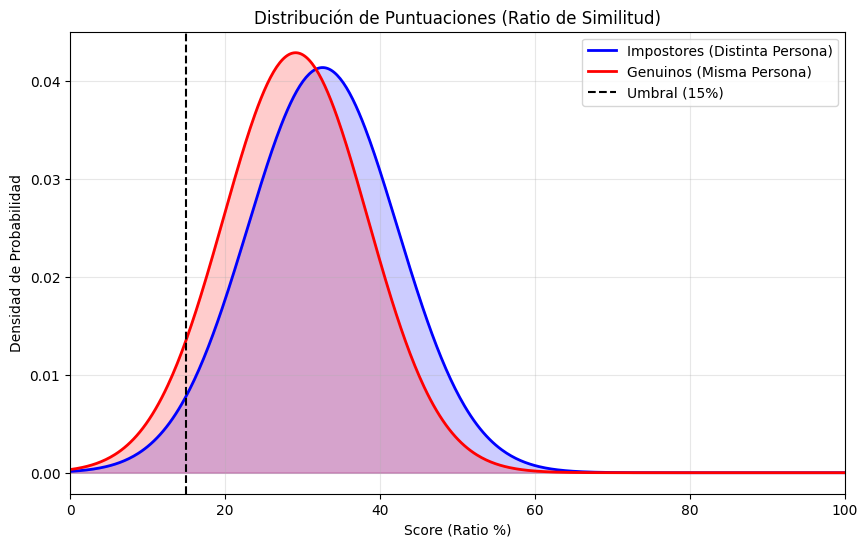

In [19]:
print("Generando gráficas de error (FAR/FRR)...")
dibujar_curvas_error(genuinos, impostores, umbral=15)

**Conclusiones**

Se puede observar como las gráficas se encuentran solapadas, lo que indica que el sistema tiene dificultades para distinguir entre los usuarios genuinos y los impostores. Esto implica que seguramente haya algun proceso del preprocesamiento que esta influyendo al mal funcionamiento de SIFT. Pudiendo ser, la aplicación del Sobel que puede estar eliminando detalles en la huella dactilar.

### Testing
Se van a utilizar un dataset que se va a guardar dentro de la carpeta `test`, donde lo que se busca es comparar las huellas dactilares con la de la base de datos para ver si existe coincidencia o no. Aquí, se busca acercarnos a un caso más realista. Para ello se ha creado la función de `procesar_y_comparar_test` que se encarga de preprocesar las imágenes de test y compararlas con la base de datos utilizando SIFT.

El resultado del SIFT se comparará con toda la base de datos y busca el que tenga mayor número de `inliners`, donde si tiene más de 12 inliners se considerará que es una coincidencia y si tiene más de 8 inliners se considerará una posible coincidencia, en caso contrario se considerará que no hay coincidencia.

In [20]:
# TEST : Función para testear (MODIFICADA: SIN PREPROCESAMIENTO INTERNO)
def procesar_y_comparar_test(
    test_path, 
    db_processed_path, 
    out_test_path,
    ventana=500, 
    paso=15
):
    """Procesa las imágenes de test ya preprocesadas y las compara contra la base de datos procesada."""

    source_path = os.path.join(out_test_path, "refinadas")
    print(f"\n[TEST] Buscando imágenes PROCESADAS en: {source_path}")
    
    if not os.path.isdir(source_path):
        print(f"[ERROR] No existe la carpeta procesada: {source_path}")
        return

    test_files = [f for f in os.listdir(source_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not test_files:
        print("[ERROR] No se encontraron imágenes procesadas.")
        return

    test_images_processed = {} 

    print(f"[TEST] Cargando {len(test_files)} imágenes para identificar...")

    for filename in test_files:
        img_path = os.path.join(source_path, filename)
        img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
        
        if img is not None:
            test_images_processed[filename] = img
            print(f"Imagen Cargada: {filename}")

    print(f"\n[AUTH] Iniciando autenticación contra la base de datos...")
    
    if not os.path.exists(db_processed_path):
        print(f"[ERROR] No existe la carpeta de datos procesados: {db_processed_path}")
        return

    sift = cv.SIFT_create(nfeatures=1500, contrastThreshold=0.01, edgeThreshold=10, sigma=1.4)
    bf = cv.BFMatcher()

    dataset_db = cargar_dataset(db_processed_path, sift)
    
    print(f"[AUTH] Comparando contra {len(dataset_db)} huellas registradas.")

    for test_name, test_img in test_images_processed.items():
        print("\n" + "-"*60)
        print(f"Identificando huella desconocida: {test_name}")

        test_img_inv = cv.bitwise_not(test_img)
        kp_test, des_test = sift.detectAndCompute(test_img_inv, None)
        
        if des_test is None:
            print("  (Warning) Sin rasgos suficientes para identificar.")
            continue
            
        mejor_match_user = "Desconocido"
        mejor_inliers = 0
        mejor_ratio = 0.0
        candidato_fichero = ""

        for db_item in dataset_db:
            inliers, ratio, _ = calcular_similitud(
                bf, kp_test, des_test, db_item['kp'], db_item['des']
            )

            if inliers > mejor_inliers and inliers >= 8:
                mejor_inliers = inliers
                mejor_ratio = ratio
                mejor_match_user = db_item['id']
                candidato_fichero = db_item['filename']

        if mejor_inliers >= 12: 
            print(f"[IDENTIFICADO] {mejor_match_user}")
            print(f"Evidencia muy fuerte: {mejor_inliers} inliers con {candidato_fichero})")
        elif mejor_inliers >= 8:
            print(f"[POSIBLE IDENTIFICACIÓN] {mejor_match_user}")
            print(f"(Evidencia moderada: {mejor_inliers} inliers con {candidato_fichero})")
        else:
            print(f"[NO IDENTIFICADO] No coincide con nadie registrado")

#### Ejecución del testing

In [21]:
print(20*"=")
print("FASE DE TEST: Identificando huellas desconocidas")
print(20*"=")

DB_PROCESSED_PATH = OUT_PATH 

procesar_y_comparar_test(TEST_PATH, DB_PROCESSED_PATH, OUT_TEST_PATH)

FASE DE TEST: Identificando huellas desconocidas

[TEST] Buscando imágenes PROCESADAS en: output/test\refinadas
[TEST] Cargando 6 imágenes para identificar...
Imagen Cargada: Huella_p1 copy 2.png
Imagen Cargada: Huella_p1 copy 3.png
Imagen Cargada: Huella_p1 copy 4.png
Imagen Cargada: Huella_p1 copy 5.png
Imagen Cargada: Huella_p1.png
Imagen Cargada: Huella_p2.png

[AUTH] Iniciando autenticación contra la base de datos...

[INFO] Cargando imágenes y generando descriptores SIFT...
[INFO] Se han cargado 20 huellas válidas.
[AUTH] Comparando contra 20 huellas registradas.

------------------------------------------------------------
Identificando huella desconocida: Huella_p1 copy 2.png
[IDENTIFICADO] crd_0811f
Evidencia muy fuerte: 1500 inliers con crd_0811f_01.png)

------------------------------------------------------------
Identificando huella desconocida: Huella_p1 copy 3.png
[IDENTIFICADO] crd_0811f
Evidencia muy fuerte: 1500 inliers con crd_0811f_01.png)

-------------------------

**Conclusiones**

Se puede observar que da buenos resultados, pero este caso es así porque los datos que se usan son copias de los datos anteriores y esta comparando huellas consigo misma, entonces no son huellas tomadas en condiciones reales.